In [1]:
# Author: Remi Flamary <remi.flamary@polytechnique.edu>
#
# License: MIT License

# sphinx_gallery_thumbnail_number = 2

import numpy as np
import matplotlib.pylab as pl
import ot
import torch

### Generate data

In [2]:
nt = 100
nt1 = 10  #

ns1 = 50
ns = 2 * ns1

rng = np.random.RandomState(2)

xt = rng.randn(nt, 2) * 0.2
xt[:nt1, 0] += 1
xt[nt1:, 1] += 1


xs1 = rng.randn(ns1, 2) * 0.2
xs1[:, 0] += 1
xs2 = rng.randn(ns1, 2) * 0.2
xs2[:, 1] += 1

xs = np.concatenate((xs1, xs2))

# Sample reweighting matrix H
H = np.zeros((ns, 2))
H[:ns1, 0] = 1 / ns1
H[ns1:, 1] = 1 / ns1
# each columns sums to 1 and has weights only for samples form the
# corresponding source distribution

M = ot.dist(xs, xt)

### Plot data

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3528416/4021933653.py:2: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xt[:, 0], xt[:, 1], label="Target $\mu^t$", alpha=0.5)
/tmp/ipykernel_3528416/4021933653.py:3: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xs1[:, 0], xs1[:, 1], label="Source $\mu^s_1$", alpha=0.5)
/tmp/ipykernel_3528416/4021933653.py:4: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xs2[:, 0], xs2[:, 1], label="Source $\mu^s_2$", alpha=0.5)


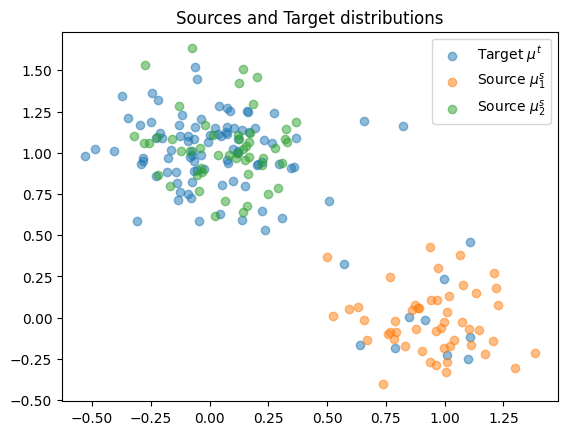

In [3]:
pl.figure(1)
pl.scatter(xt[:, 0], xt[:, 1], label="Target $\mu^t$", alpha=0.5)
pl.scatter(xs1[:, 0], xs1[:, 1], label="Source $\mu^s_1$", alpha=0.5)
pl.scatter(xs2[:, 0], xs2[:, 1], label="Source $\mu^s_2$", alpha=0.5)
pl.title("Sources and Target distributions")
pl.legend()

### Optimization of the model wrt the Wasserstein distance

In [4]:
# convert numpy arrays to torch tensors
H2 = torch.tensor(H)
M2 = torch.tensor(M)

# weights for the source distributions
w = torch.tensor(ot.unif(2), requires_grad=True)

# uniform weights for target
b = torch.tensor(ot.unif(nt))

lr = 2e-3  # learning rate
niter = 500  # number of iterations
losses = []  # loss along the iterations

# loss for the minimal Wasserstein estimator


def get_loss(w):
    a = torch.mv(H2, w)  # distribution reweighting
    return ot.emd2(a, b, M2)  # squared Wasserstein 2


for i in range(niter):
    loss = get_loss(w)
    losses.append(float(loss))

    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad  # gradient step
        w[:] = ot.utils.proj_simplex(w)  # projection on the simplex

    w.grad.zero_()

/tmp/ipykernel_3528416/926394883.py:25: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss))


### Estimated weights and convergence of the objective

Estimated mixture: [0.09980706 0.90019294]


Text(0.5, 0, 'Iterations')

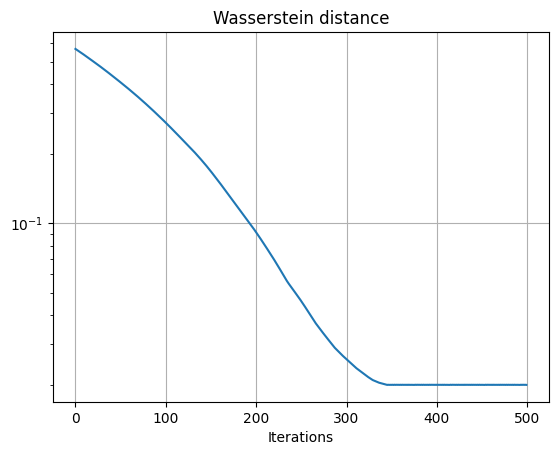

In [5]:
we = w.detach().numpy()
print("Estimated mixture:", we)

pl.figure(2)
pl.semilogy(losses)
pl.grid()
pl.title("Wasserstein distance")
pl.xlabel("Iterations")

### Plotting the reweighted source distribution

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3528416/3547814314.py:6: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xt[:, 0], xt[:, 1], label="Target $\mu^t$", alpha=0.5)
/tmp/ipykernel_3528416/3547814314.py:12: SyntaxWarning: invalid escape sequence '\s'
  label="Weighted sources $\sum_{k} w_k\mu^s_k$",


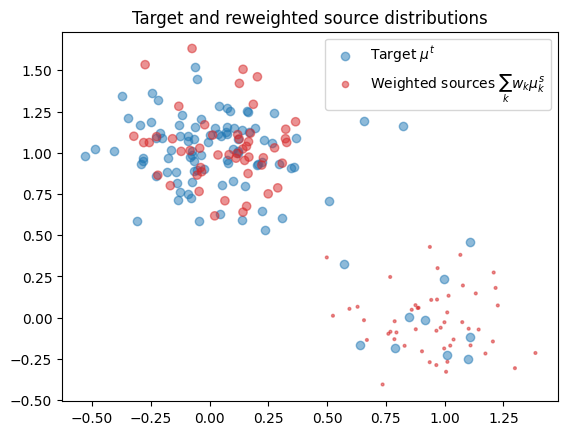

In [6]:
pl.figure(3)

# compute source weights
ws = H.dot(we)

pl.scatter(xt[:, 0], xt[:, 1], label="Target $\mu^t$", alpha=0.5)
pl.scatter(
    xs[:, 0],
    xs[:, 1],
    color="C3",
    s=ws * 20 * ns,
    label="Weighted sources $\sum_{k} w_k\mu^s_k$",
    alpha=0.5,
)
pl.title("Target and reweighted source distributions")
pl.legend()